# Speaker Regconition Tutorial

In [ ]:
# Should run these commands in the terminal
!apt-get install git-lfs
!git lfs install

In [1]:
!pwd

PR_DIR='/home/rnd/tts/hieng-tts/espnet/'

/home/rnd/tts/hieng-tts/espnet/tools


## ESPnet installation

In [3]:
%cd $PR_DIR/tools
!./setup_anaconda.sh anaconda espnet 3.8

/home/rnd/tts/hieng-tts/espnet/tools
Channels:
 - defaults
Platform: linux-64
Solving environment: done

# All requested packages already installed.

Channels:
 - defaults
Platform: linux-64
Solving environment: done

# All requested packages already installed.



In [7]:
!which python && python --version

/home/rnd/tts/hieng-tts/espnet/tools/anaconda/envs/espnet/bin/python
Python 3.8.20


In [5]:
!cat activate_python.sh

#!/usr/bin/env bash
# THIS FILE IS GENERATED BY tools/setup_anaconda.sh
if [ -z "${PS1:-}" ]; then
    PS1=__dummy__
fi
. /home/rnd/tts/hieng-tts/espnet/tools/anaconda/etc/profile.d/conda.sh && conda deactivate && conda activate espnet


In [4]:
!chmod +x activate_python.sh

In [8]:
%cd $PR_DIR/tools
!make TH_VERSION=1.12.1 CUDA_VERSION=11.4

/home/rnd/tts/hieng-tts/espnet/tools
CUDA_VERSION=11.4
PYTHON=/home/rnd/tts/hieng-tts/espnet/tools/anaconda/envs/espnet/bin/python3
PYTHON_VERSION=Python 3.8.20
USE_CONDA=1
TH_VERSION=1.12.1
WITH_OMP=ON
. ./activate_python.sh && python3 -m pip install packaging
touch packaging.done
. ./activate_python.sh && python3 -m pip install -U numba
touch numba.done
. ./activate_python.sh && ./installers/install_torch.sh "true" "1.12.1" "11.4"
2025-02-11T15:09:53 (install_torch.sh:139:main) [INFO] python_version=3.8.20
2025-02-11T15:09:53 (install_torch.sh:140:main) [INFO] torch_version=1.12.1
2025-02-11T15:09:53 (install_torch.sh:141:main) [INFO] cuda_version=11.4
2025-02-11T15:09:53 (install_torch.sh:133:check_cuda_version) [WARNING] Pre-build package for Pytorch=1.12.1 with CUDA=11.4 is not provided.
2025-02-11T15:09:53 (install_torch.sh:176:main) [INFO] Fallback: cuda_version=11.4 -> cuda_version=11.6
2025-02-11T15:09:53 (install_torch.sh:90:install_torch) conda install -y pytorch=1.12.1 torc

In [24]:
%cd $PR_DIR/tools
!. ./activate_python.sh && pip install typeguard==2.7.1

/home/rnd/tts/hieng-tts/espnet/tools
  Using cached typeguard-2.7.1-py3-none-any.whl.metadata (3.4 kB)
Using cached typeguard-2.7.1-py3-none-any.whl (15 kB)
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.0.1
    Uninstalling typeguard-4.0.1:
      Successfully uninstalled typeguard-4.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.7.1 which is incompatible.


In [11]:
!. ./activate_python.sh && installers/install_speechbrain.sh
!. ./activate_python.sh && installers/install_rawnet.sh
!. ./activate_python.sh && pip install ipykernel

speechbrain is already installed.
[INFO] torch_version=1.12.1
Cloning into 'RawNet'...
remote: Enumerating objects: 619, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 619 (delta 38), reused 45 (delta 25), pack-reused 536 (from 1)
Receiving objects: 100% (619/619), 180.00 MiB | 10.61 MiB/s, done.
Resolving deltas: 100% (319/319), done.
Updating files: 100% (65/65), done.
Submodule 'python/RawNet3/models/weights' (https://huggingface.co/jungjee/RawNet3) registered for path 'python/RawNet3/models/weights'
Cloning into '/home/rnd/tts/hieng-tts/espnet/tools/RawNet/python/RawNet3/models/weights'...
Submodule path 'python/RawNet3/models/weights': checked out 'e4b2908d2b65ef7ff91e52ba176effc6e6256678'


## Speaker Recognition

### Dataset

In [12]:
%cd $PR_DIR/tools
!. ./activate_python.sh && pip install kaldiio soundfile tqdm librosa matplotlib IPython

/home/rnd/tts/hieng-tts/espnet/tools


In [9]:
!git clone https://github.com/kaldi-asr/kaldi.git

fatal: destination path 'kaldi' already exists and is not an empty directory.


In [30]:
%cd $PR_DIR/egs2/mini_librispeech/sid1
!ls -l

/home/rnd/tts/hieng-tts/espnet/egs2/mini_librispeech/sid1
total 63808
lrwxrwxrwx 1 rnd rnd       26 Feb 11 08:11 asr.sh -> ../../TEMPLATE/asr1/asr.sh
-rw-rw-r-- 1 rnd rnd     4231 Feb 11 08:11 cmd.sh
drwxrwxr-x 2 rnd rnd     4096 Feb 11 08:11 conf
drwxrwxr-x 7 rnd rnd     4096 Feb 11 15:33 data
lrwxrwxrwx 1 rnd rnd       25 Feb 11 08:11 db.sh -> ../../TEMPLATE/asr1/db.sh
drwxrwxr-x 3 rnd rnd     4096 Feb 11 13:43 downloads
drwxrwxr-x 4 rnd rnd     4096 Feb 11 14:00 dump
drwxrwxr-x 2 rnd rnd     4096 Feb 11 14:20 local
-rw-rw-r-- 1 rnd rnd 65297133 Jun 21  2022 model.pt
lrwxrwxrwx 1 rnd rnd       27 Feb 11 08:11 path.sh -> ../../TEMPLATE/asr1/path.sh
lrwxrwxrwx 1 rnd rnd       29 Feb 11 08:11 pyscripts -> ../../TEMPLATE/asr1/pyscripts
-rwxrwxr-x 1 rnd rnd      724 Feb 11 08:11 run.sh
-rwxrwxr-x 1 rnd rnd      816 Feb 11 08:11 run_xvector.sh
-rwxrwxr-x 1 rnd rnd      828 Feb 11 08:11 run_xvector_speechbrain.sh
lrwxrwxrwx 1 rnd rnd       27 Feb 11 08:11 scripts -> ../../TEMPLATE/asr1/scri

### Data Preparation

In [5]:
%cd $PR_DIR/egs2/mini_librispeech/sid1

/home/rnd/tts/hieng-tts/espnet/egs2/mini_librispeech/sid1


In [14]:
!./run.sh --stage 1 --stop_stage 1

2025-02-11T15:14:36 (asr.sh:267:main) ./asr.sh --train_set train --valid_set dev --test_sets test --ngpu 1 --asr_config conf/train_sid_transformer.yaml --use_lm false --inference_config conf/decode_sid.yaml --inference_nj 5 --token_type word --local_data_opts --stage 0 --stage 1 --stop_stage 1
2025-02-11T15:14:37 (asr.sh:495:main) Stage 1: Data preparation for data/train, data/dev, etc.
 Stage 0: prepare data
local/download_and_untar.sh: data part train-clean-5 was already successfully extracted, nothing to do.
Stage 1: Prepare Kaldi-style train-test
./utils/copy_data_dir.sh: copied data from data/train_clean_5 to data/train
utils/validate_data_dir.sh: Successfully validated data-directory data/train
fix_data_dir.sh: kept 152 utterances out of 1519
Unable to flush stdout: Broken pipe
fix_data_dir.sh: old files are kept in data/train/.backup
./utils/copy_data_dir.sh: copied data from data/train_clean_5 to data/dev
utils/validate_data_dir.sh: Successfully validated data-directory data/de

### Data Preprocessing

In [26]:
%cd $PR_DIR/egs2/mini_librispeech/sid1

/home/rnd/tts/hieng-tts/espnet/egs2/mini_librispeech/sid1


In [27]:
!./run.sh --stage 2 --stop_stage 5

2025-02-11T16:08:27 (asr.sh:267:main) ./asr.sh --train_set train --valid_set dev --test_sets test --ngpu 1 --asr_config conf/train_sid_transformer.yaml --use_lm false --inference_config conf/decode_sid.yaml --inference_nj 5 --token_type word --local_data_opts --stage 0 --stage 2 --stop_stage 5
2025-02-11T16:08:28 (asr.sh:518:main) Skip stage 2: Speed perturbation
2025-02-11T16:08:28 (asr.sh:528:main) Stage 3: Format wav.scp: data/ -> dump/raw
utils/copy_data_dir.sh: copied data from data/train to dump/raw/org/train
utils/validate_data_dir.sh: Successfully validated data-directory dump/raw/org/train
2025-02-11T16:08:29 (format_wav_scp.sh:43:main) scripts/audio/format_wav_scp.sh --nj 32 --cmd run.pl --audio-format flac --fs 16k data/train/wav.scp dump/raw/org/train
2025-02-11T16:08:30 (format_wav_scp.sh:112:main) [info]: without segments
2025-02-11T16:08:31 (format_wav_scp.sh:144:main) Successfully finished. [elapsed=2s]
utils/copy_data_dir.sh: copied data from data/dev to dump/raw/org/d

### Use Pre-trained speaker representation

In [28]:
!cat ./local/extract_xvector.sh

#!/bin/bash
  
# Copyright 2023 Carnegie Mellon University (Jiatong Shi)
# Apache 2.0  (http://www.apache.org/licenses/LICENSE-2.0)

. ./path.sh || exit 1;
. ./cmd.sh || exit 1;
. ./db.sh || exit 1;

mkdir -p dump/extracted

if [ ! -f "model.pt" ]; then
    wget https://huggingface.co/jungjee/RawNet3/resolve/main/model.pt
fi

for dset in train dev test; do
    datadir=dump/raw/${dset}
    outdir=dump/extracted/${dset}
    cp -r ${datadir} ${outdir}
    python3 pyscripts/utils/extract_xvectors.py --toolkit rawnet \
        --pretrained_model model.pt --draw_tsne true --tsne_n_spk 10 \
       ${datadir} ${outdir}

    cp ${outdir}/xvector.scp ${outdir}/feats.scp
    echo "256" > ${outdir}/feats_dim
    echo "xvector" > ${outdir}/feats_type
done



In [31]:
import os
from pathlib import Path

tools_dir = Path(os.getcwd()).parent.parent.parent / "tools"
model  = tools_dir / "RawNet/python/RawNet3/models/weights/model.pt"
model

PosixPath('/home/rnd/tts/hieng-tts/espnet/tools/RawNet/python/RawNet3/models/weights/model.pt')

#### Resolve model.pt not downloaded
See `tools/installers/install_rawnet.sh` for detail.
- Option 1: try manually
```
cd RawNet
git submodule update --init --recursive
```
- Option 2: Clone Rawnet to anywhere and follow Option 1 above, check if model.pt is downloaded (not a text file), copy the model.pt into your work dir.

In [32]:
!./local/extract_xvector.sh

self.encoder_type ECA
100%|███████████████████████████████████████████| 29/29 [00:16<00:00,  1.76it/s]
self.encoder_type ECA
100%|███████████████████████████████████████████| 29/29 [00:08<00:00,  3.54it/s]
self.encoder_type ECA
100%|███████████████████████████████████████████| 29/29 [00:14<00:00,  2.02it/s]


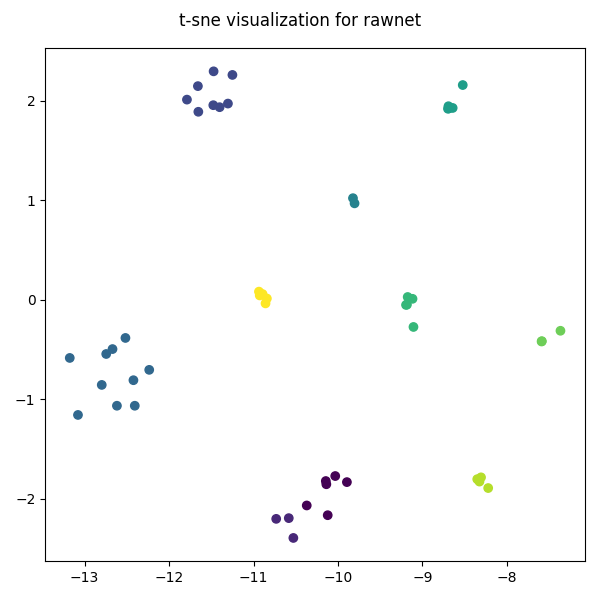

In [33]:
from IPython.display import Image, display
display(Image('dump/extracted/train/tsne.png'))

#### Extract speaker embedding from SpeechBrain

In [34]:
!cat ./local/extract_xvector_speechbrain.sh
!./local/extract_xvector_speechbrain.sh

#!/bin/bash
  
# Copyright 2023 Carnegie Mellon University (Jiatong Shi)
# Apache 2.0  (http://www.apache.org/licenses/LICENSE-2.0)

. ./path.sh || exit 1;
. ./cmd.sh || exit 1;
. ./db.sh || exit 1;

mkdir -p dump/extracted_speechbrain


for dset in train dev test; do
    datadir=dump/raw/${dset}
    outdir=dump/extracted_speechbrain/${dset}
    cp -r ${datadir} ${outdir}
    python3 pyscripts/utils/extract_xvectors.py --toolkit speechbrain \
       --pretrained_model speechbrain/spkrec-xvect-voxceleb --draw_tsne true --tsne_n_spk 10 \
       ${datadir} ${outdir}

    cp ${outdir}/xvector.scp ${outdir}/feats.scp
    echo "512" > ${outdir}/feats_dim
    echo "xvector" > ${outdir}/feats_type
done

2025-02-11 19:35:16,720 (train_logger:227) WARNING: torchvision is not available - cannot save figures
2025-02-11 19:35:16,806 (fetching:118) INFO: Fetch hyperparams.yaml: Delegating to Huggingface hub, source speechbrain/spkrec-xvect-voxceleb.
hyperparams.yaml: 100%|█████████████████████| 2.04

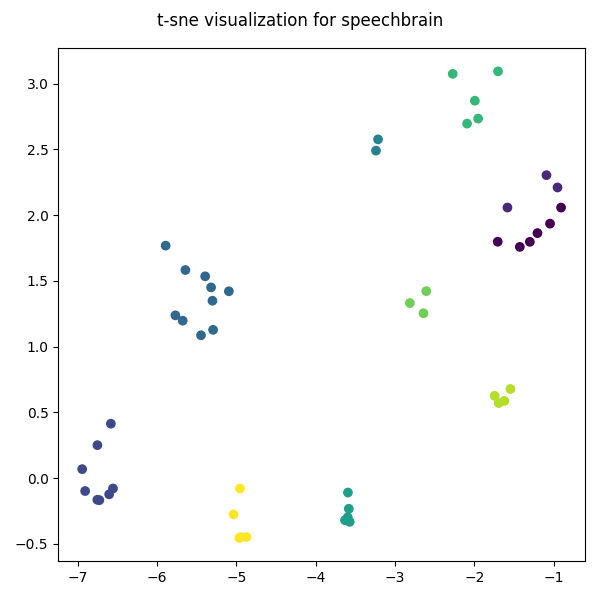

In [35]:
from IPython.display import Image, display
display(Image('dump/extracted_speechbrain/train/tsne.png'))

#### Training for speaker recognition

In [ ]:
!pip install Pillow==9.4.0

In [37]:
!cat ./run_xvector_speechbrain.sh

#!/usr/bin/env bash

# Copyright 2023 Jiatong Shi
#  Apache 2.0  (http://www.apache.org/licenses/LICENSE-2.0)
#
# Set bash to 'debug' mode, it will exit on :
# -e 'error', -u 'undefined variable', -o ... 'error in pipeline', -x 'print commands',

set -e
set -u
set -o pipefail

train_set=train
valid_set=dev
test_sets=test

train_config=conf/train_sid_transformer_xvector.yaml
decode_config=conf/decode_sid.yaml

./asr.sh \
    --stage 10 \
    --feats_type extracted_speechbrain \
    --feats_normalize utterance_mvn \
    --train_set "${train_set}" \
    --valid_set "${valid_set}" \
    --test_sets "${test_sets}" \
    --ngpu 1 \
    --asr_config "${train_config}" \
    --use_lm false \
    --inference_config "${decode_config}" \
    --inference_nj 5 \
    --token_type word \
    --local_data_opts "--stage 0" \
    "$@"


In [38]:
!./run_xvector_speechbrain.sh

2025-02-11T19:48:32 (asr.sh:267:main) ./asr.sh --stage 10 --feats_type extracted_speechbrain --feats_normalize utterance_mvn --train_set train --valid_set dev --test_sets test --ngpu 1 --asr_config conf/train_sid_transformer_xvector.yaml --use_lm false --inference_config conf/decode_sid.yaml --inference_nj 5 --token_type word --local_data_opts --stage 0
2025-02-11T19:48:33 (asr.sh:1008:main) Stage 6-8: Skip lm-related stages: use_lm=false
2025-02-11T19:48:33 (asr.sh:1029:main) Stage 10: ASR collect stats: train_set=dump/extracted_speechbrain/train, valid_set=dump/extracted_speechbrain/dev
2025-02-11T19:48:33 (asr.sh:1079:main) Generate 'exp/asr_stats_extracted_speechbrain_word/run.sh'. You can resume the process from stage 10 using this script
2025-02-11T19:48:33 (asr.sh:1083:main) ASR collect-stats started... log: 'exp/asr_stats_extracted_speechbrain_word/logdir/stats.*.log'
/home/rnd/tts/hieng-tts/espnet/tools/anaconda/envs/espnet/bin/python3 /home/rnd/tts/hieng-tts/espnet/espnet2/bi